# PyGAGE, explained from the beginning

PyGAGE tests **groups of genes** instead of looking at only one gene at a time.

A gene set can represent a pathway. If many genes in that pathway move together, PyGAGE can report that pathway as enriched.

This notebook covers:

1. a tiny example you can understand by looking at it;
2. all three tests and both ways of combining results;
3. the new large repository data table;
4. saved charts, command-line outputs, and numerical R GAGE checks.

In [1]:
from pathlib import Path
import json
import os
import sys

HERE = Path.cwd().resolve()
SEARCH_FOLDERS = (HERE, *HERE.parents)
PROJECT_CANDIDATES = (
    *SEARCH_FOLDERS,
    *(folder / "pygage-pathview-validation" for folder in SEARCH_FOLDERS),
)
ROOT = next(
    (
        folder for folder in PROJECT_CANDIDATES
        if (folder / ".venv").exists() and (folder / "scripts").exists()
    ),
    HERE,
)

os.environ.setdefault("MPLBACKEND", "Agg")
os.environ.setdefault("MPLCONFIGDIR", str(ROOT / ".mplconfig"))
print("Validation folder:", ROOT)

Validation folder: /Users/summermalik/Desktop/PATHVIEW-MARKDOWN/pygage-pathview-validation


In [2]:
import numpy as np
import polars as pl
import pygage
from pygage import GAGEAnalysis, GAGEPreparation, load_gmt, read_matrix
from pygage.visualization_utils import EnrichmentPlots
from IPython.display import Image, display

print("PyGAGE version:", pygage.__version__)
print("Python version:", sys.version.split()[0])

PyGAGE version: 1.2.1
Python version: 3.14.3


## Part 1 — Read a very small expression table

- Each **row** is one gene.
- `control_1` and `control_2` are reference samples.
- `treatment_1` and `treatment_2` are treatment samples.
- Genes `g01` through `g10` were designed to increase.
- Genes `g11` through `g20` were designed to decrease.

In [3]:
expression = read_matrix(ROOT / "data" / "toy_expression.csv")
gene_sets = load_gmt(ROOT / "data" / "toy_sets.gmt")
print("Table shape (genes, columns):", expression.shape)
expression.head(8)

Table shape (genes, columns): (30, 5)


gene_id,control_1,control_2,treatment_1,treatment_2
str,f64,f64,f64,f64
"""g01""",5.0,5.2,8.1,8.0
"""g02""",4.8,5.0,7.8,7.6
"""g03""",5.1,5.0,7.4,7.5
"""g04""",4.9,5.1,7.1,7.3
"""g05""",5.0,4.9,6.9,7.0
"""g06""",5.1,5.2,6.8,6.7
"""g07""",5.0,5.0,6.5,6.6
"""g08""",4.9,5.1,6.3,6.4


## Part 2 — Turn expression into treatment-minus-control values

PyGAGE uses positions starting at zero. Among the sample columns:

- controls are positions `0` and `1`;
- treatments are positions `2` and `3`.

`comparison="paired"` subtracts each matched control from its matched treatment.

In [4]:
prepared = GAGEPreparation.prepare_expression(
    expression,
    ref_indices=[0, 1],
    samp_indices=[2, 3],
    comparison="paired",
)
prepared.head(8)

gene_id,treatment_1,treatment_2
str,f64,f64
"""g01""",3.1,2.8
"""g02""",3.0,2.6
"""g03""",2.3,2.5
"""g04""",2.2,2.2
"""g05""",1.9,2.1
"""g06""",1.7,1.5
"""g07""",1.5,1.6
"""g08""",1.4,1.3


Positive numbers mean the treatment is higher. Negative numbers mean the treatment is lower.

In [5]:
analysis = GAGEAnalysis()
result = analysis.run_gage(
    prepared,
    gene_sets,
    set_size_range=(5, 50),
    test_method="t-test",
    meta_method="stouffer",
    compute_effect=True,
    leading_edge=True,
)

print("Top pathways that increased:")
display(result["greater"].head())
print("Top pathways that decreased:")
display(result["less"].head())

Top pathways that increased:


gene_set,set_size,stat_mean,p_geomean,p_val,q_val,effect,leading_edge
str,i64,f64,f64,f64,f64,f64,str
"""UP_SET""",10,3.283343,0.002761,0.000043,0.000174,1.86,"""g01;g02;g03;g04;g05"""
"""MIXED_SET""",10,0.035747,0.485912,0.480146,0.960292,0.26,"""g01;g02;g03"""
"""UNCHANGED_SET""",10,-0.510304,0.688414,0.757143,0.999812,0.01,"""g28;g21"""
"""DOWN_SET""",10,-2.945822,0.99399,0.999812,0.999812,-1.17,"""g20;g19;g18;g17;g16"""


Top pathways that decreased:


gene_set,set_size,stat_mean,p_geomean,p_val,q_val,effect,leading_edge
str,i64,f64,f64,f64,f64,f64,str
"""DOWN_SET""",10,-2.945822,0.005957,0.000188,0.000754,-1.17,"""g20;g19;g18;g17;g16"""
"""UNCHANGED_SET""",10,-0.510304,0.310663,0.242857,0.485715,0.01,"""g28;g21"""
"""MIXED_SET""",10,0.035747,0.513994,0.519854,0.693139,0.26,"""g01;g02;g03"""
"""UP_SET""",10,3.283343,0.997237,0.999957,0.999957,1.86,"""g01;g02;g03;g04;g05"""


`p_val` measures evidence before multiple-testing correction. `q_val` is the Benjamini–Hochberg corrected value. Smaller values mean stronger evidence.

## Part 3 — Check every statistic/meta-method combination

PyGAGE currently offers three gene-set tests:

- **t-test:** compares the pathway mean with the background and includes variance;
- **z-test:** a PAGE-style standardized mean comparison;
- **KS test:** compares ranked distributions and is less tied to a normal-distribution assumption.

It can combine sample-level evidence with:

- **Stouffer:** combines normalized p-value scores;
- **Fisher:** combines the logarithms of p-values.

In [6]:
method_rows = []
for test_method in ("t-test", "z-test", "ks-test"):
    for meta_method in ("stouffer", "fisher"):
        tested = GAGEAnalysis().run_gage(
            prepared,
            gene_sets,
            set_size_range=(5, 50),
            test_method=test_method,
            meta_method=meta_method,
        )
        method_rows.append({
            "test": test_method,
            "combine": meta_method,
            "top_greater": tested["greater"]["gene_set"][0],
            "top_less": tested["less"]["gene_set"][0],
            "tested_sets": tested["greater"].height,
        })
pl.DataFrame(method_rows)

test,combine,top_greater,top_less,tested_sets
str,str,str,str,i64
"""t-test""","""stouffer""","""UP_SET""","""DOWN_SET""",4
"""t-test""","""fisher""","""UP_SET""","""DOWN_SET""",4
"""z-test""","""stouffer""","""UP_SET""","""DOWN_SET""",4
"""z-test""","""fisher""","""UP_SET""","""DOWN_SET""",4
"""ks-test""","""stouffer""","""UP_SET""","""DOWN_SET""",4
"""ks-test""","""fisher""","""UP_SET""","""DOWN_SET""",4


## Part 4 — What the PyGAGE charts mean

- **Bubble plot:** one bubble per pathway. Horizontal position is the pathway statistic, color is significance, and bubble size is the number of genes.
- **Enrichment heatmap:** compares pathway statistics across conditions.
- **Running enrichment plot:** walks down a ranked gene list and shows where pathway genes cluster.
- **Pathway gene-color chart:** gives every pathway gene a fold-change color that can be handed to a pathway renderer.

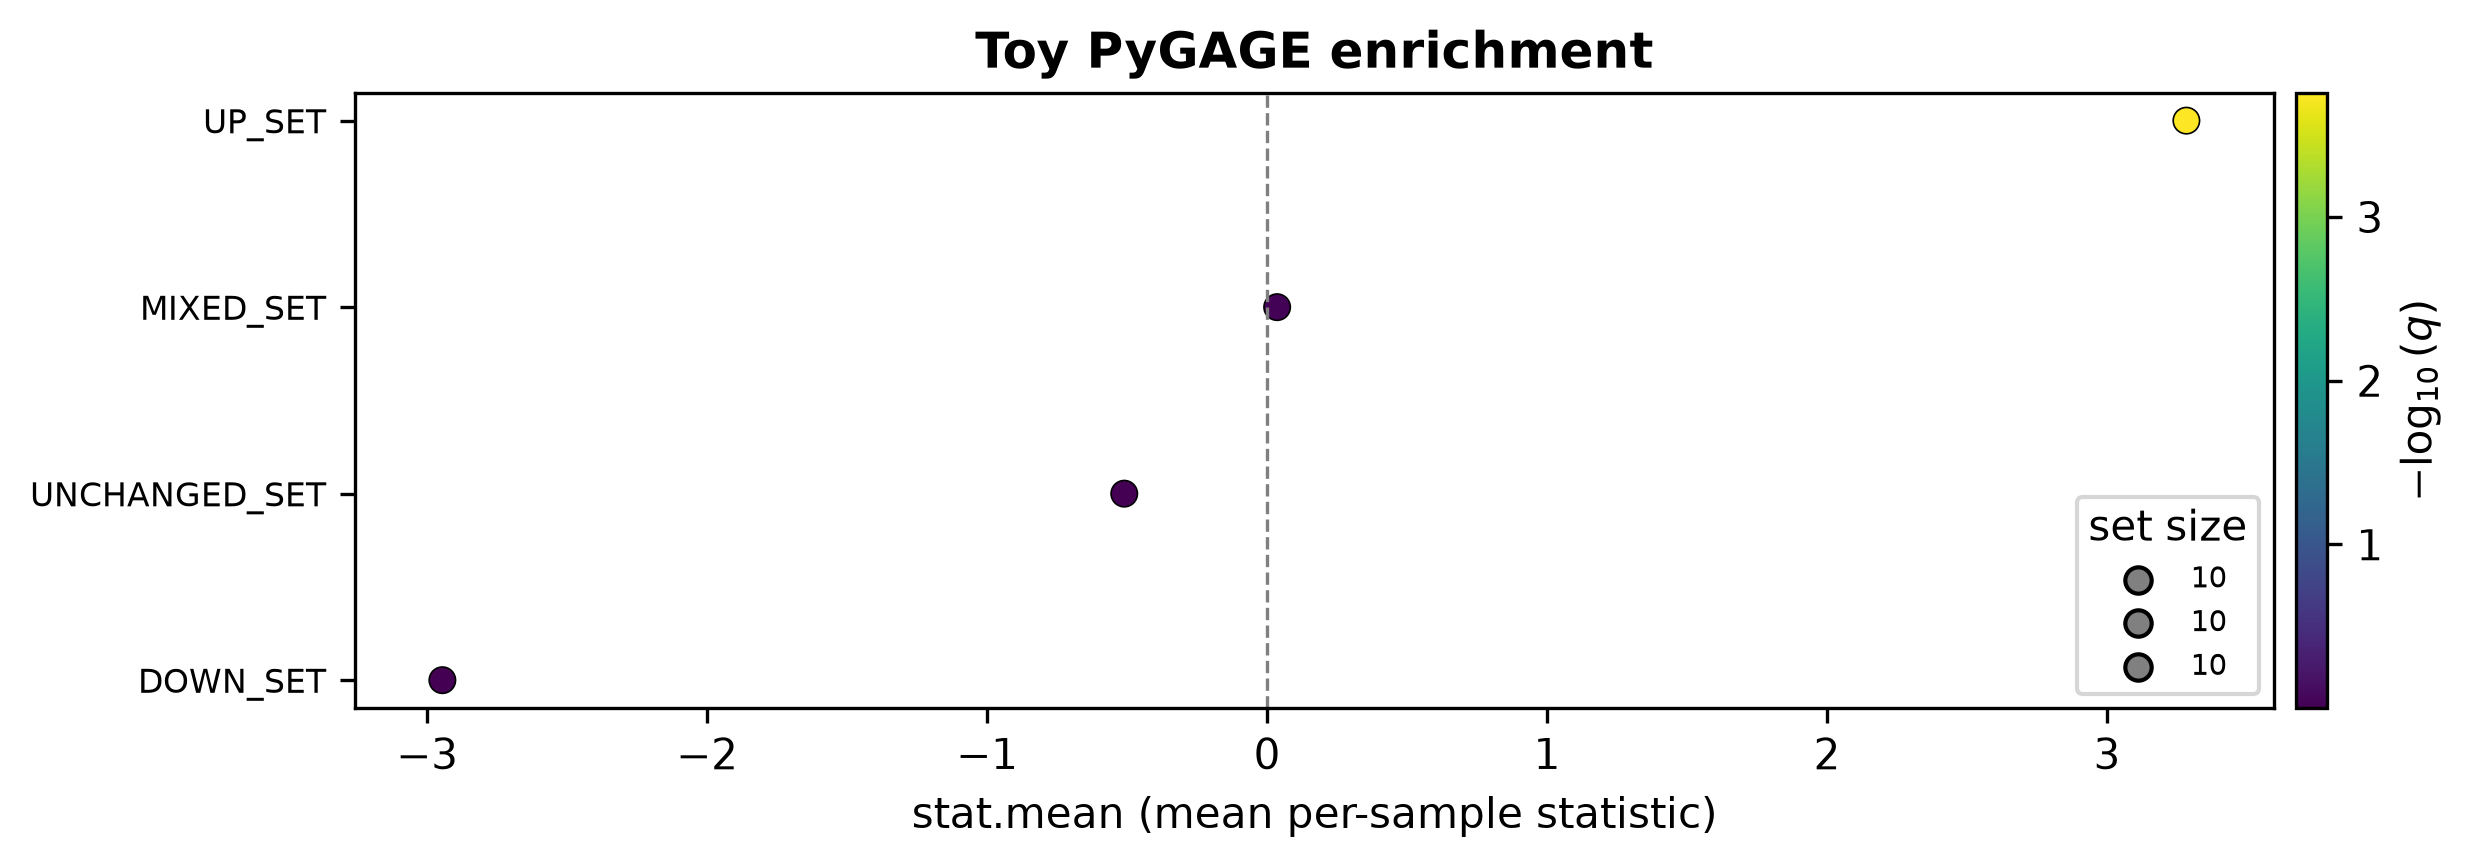

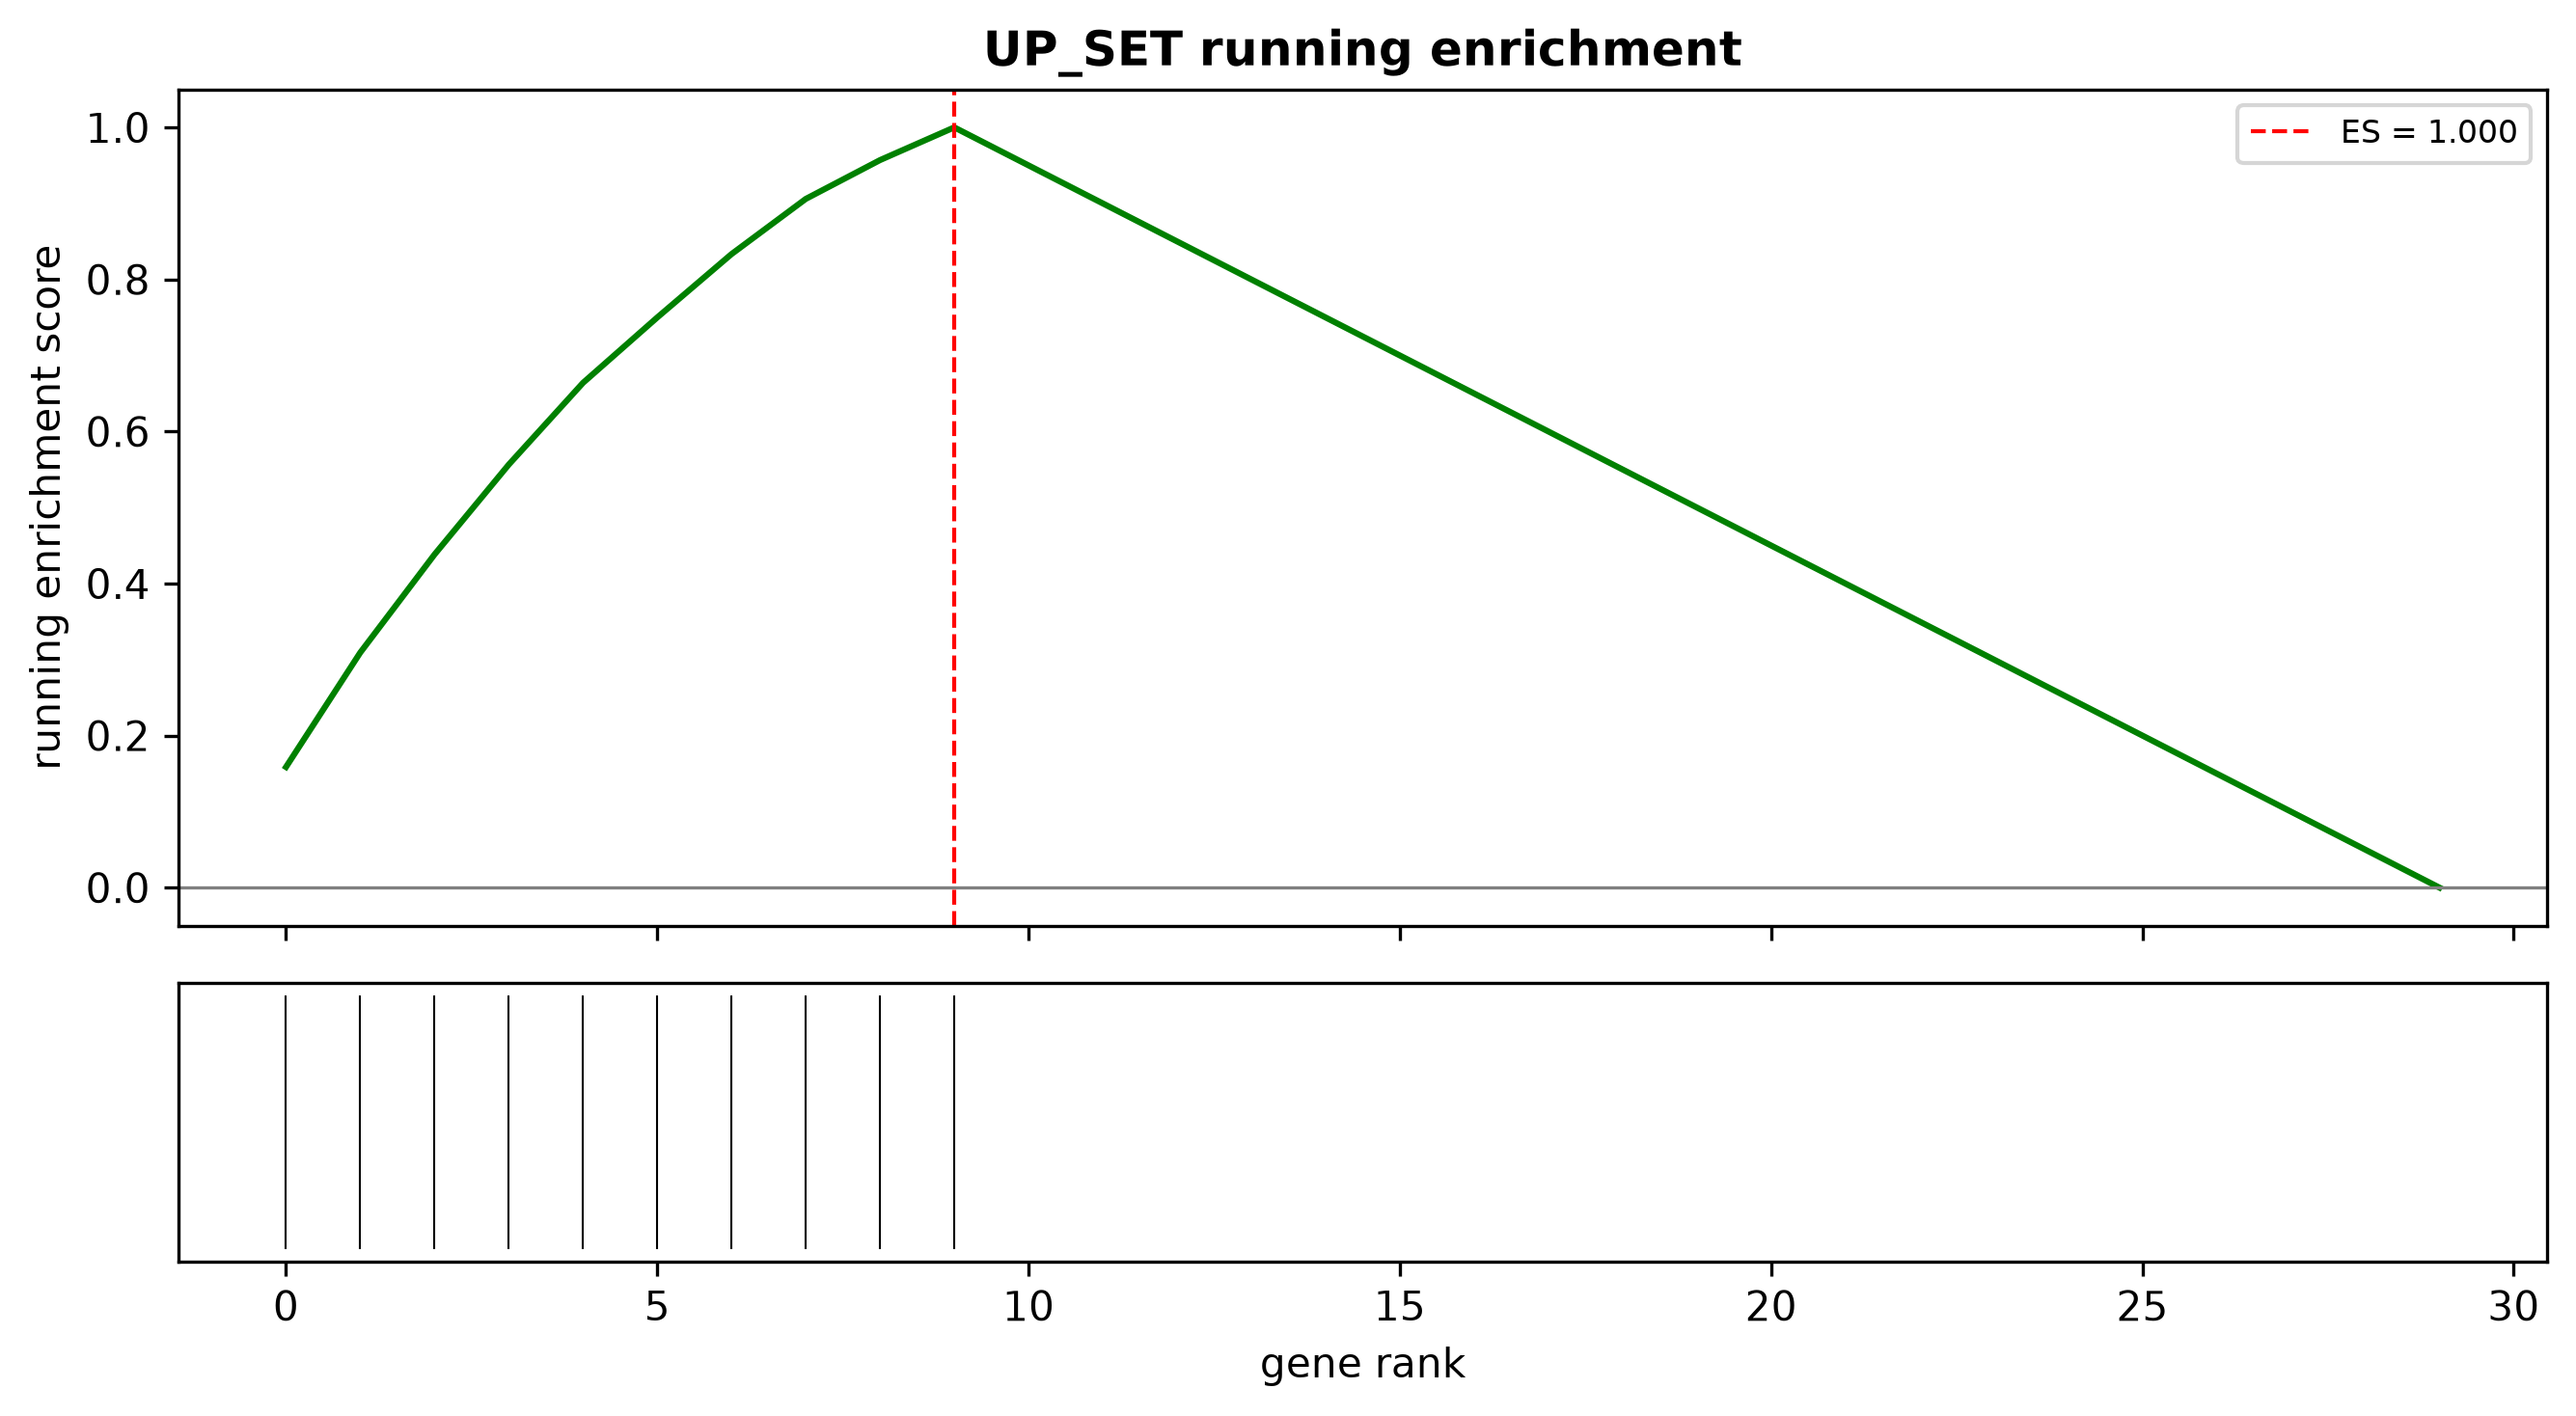

In [7]:
bubble = ROOT / "results" / "pygage" / "toy_bubble.png"
running = ROOT / "results" / "pygage" / "toy_running_enrichment.png"
display(Image(filename=str(bubble), width=700))
display(Image(filename=str(running), width=700))

## Part 5 — The new large repository data table

The newest PyGAGE repository commit adds one file. It has 19,469 genes and 198 TCGA-style sample columns.

The sample endings identify 184 `.01`, 13 `.11`, and one `.06` sample. The careful classical design uses the **13 patient-matched `.11`/`.01` pairs**. It does not incorrectly pair all 184 primary samples with 13 normal samples.

The repository filename says `GDS3627`, but its columns use TCGA identifiers. Confirm the dataset's exact provenance before describing it in a publication.

In [8]:
new_expression = read_matrix(
    ROOT / "data" / "upstream_pygage" / "GDS3627_exp_formatted.csv"
)
sample_columns = new_expression.columns[1:]

def patient(sample):
    return ".".join(sample.split(".")[:3])

primary = {
    patient(sample): sample
    for sample in sample_columns
    if sample.endswith(".01")
}
normal = [
    sample for sample in sample_columns
    if sample.endswith(".11") and patient(sample) in primary
]
tumor = [primary[patient(sample)] for sample in normal]

design = pl.DataFrame({
    "patient": [patient(sample) for sample in normal],
    "normal_reference": normal,
    "matched_primary_sample": tumor,
})
print("Expression shape:", new_expression.shape)
print("Matched pairs:", design.height)
design

Expression shape: (19469, 199)
Matched pairs: 13


patient,normal_reference,matched_primary_sample
str,str,str
"""TCGA.L5.A4OO""","""TCGA.L5.A4OO.11""","""TCGA.L5.A4OO.01"""
"""TCGA.V5.A7RE""","""TCGA.V5.A7RE.11""","""TCGA.V5.A7RE.01"""
"""TCGA.L5.A4OQ""","""TCGA.L5.A4OQ.11""","""TCGA.L5.A4OQ.01"""
"""TCGA.IC.A6RE""","""TCGA.IC.A6RE.11""","""TCGA.IC.A6RE.01"""
"""TCGA.IC.A6RF""","""TCGA.IC.A6RF.11""","""TCGA.IC.A6RF.01"""
…,…,…
"""TCGA.L5.A4OJ""","""TCGA.L5.A4OJ.11""","""TCGA.L5.A4OJ.01"""
"""TCGA.V5.AASX""","""TCGA.V5.AASX.11""","""TCGA.V5.AASX.01"""
"""TCGA.L5.A4OM""","""TCGA.L5.A4OM.11""","""TCGA.L5.A4OM.01"""


In [9]:
ref_indices = [sample_columns.index(sample) for sample in normal]
samp_indices = [sample_columns.index(sample) for sample in tumor]

new_prepared = GAGEPreparation.prepare_expression(
    new_expression,
    ref_indices=ref_indices,
    samp_indices=samp_indices,
    comparison="paired",
    input_logged=True,
)
upstream_sets = json.loads(
    (ROOT / "data" / "upstream_pygage" / "kegg_gs.json").read_text()
)
new_result = GAGEAnalysis().run_gage(
    new_prepared,
    upstream_sets,
    test_method="t-test",
    meta_method="stouffer",
)
print("Prepared shape:", new_prepared.shape)
print("Top greater pathways:")
display(new_result["greater"].head(8))
print("Top less pathways:")
display(new_result["less"].head(8))

Prepared shape: (19469, 14)
Top greater pathways:


gene_set,set_size,stat_mean,p_geomean,p_val,q_val,effect
str,i64,f64,f64,f64,f64,f64
"""hsa04110 Cell cycle""",124,4.662963,6.6579e-7,5.3272e-60,8.6300e-58,0.869951
"""hsa03030 DNA replication""",36,3.781851,0.000079,5.9830e-37,4.8463e-35,1.043758
"""hsa03040 Spliceosome""",123,3.500403,0.000098,3.7273e-35,2.0127e-33,0.598303
"""hsa03050 Proteasome""",43,3.454594,0.000306,3.7449e-32,1.5167e-30,0.860571
"""hsa03008 Ribosome biogenesis i…",69,2.805996,0.001236,5.8936e-23,1.9095e-21,0.6366
"""hsa03013 RNA transport""",144,2.733672,0.000783,1.7895e-22,4.8317e-21,0.502494
"""hsa00240 Pyrimidine metabolism""",94,2.382079,0.005282,1.2188e-17,2.8206e-16,0.572463
"""hsa03410 Base excision repair""",33,2.377346,0.006372,1.0454e-16,2.1169e-15,0.755811


Top less pathways:


gene_set,set_size,stat_mean,p_geomean,p_val,q_val,effect
str,i64,f64,f64,f64,f64,f64
"""hsa04740 Olfactory transductio…",380,-3.740444,0.000015,1.1686e-40,1.8932e-38,-0.002199
"""hsa04971 Gastric acid secretio…",74,-2.170117,0.01117,8.5707e-15,6.9423e-13,-0.398412
"""hsa00071 Fatty acid metabolism""",43,-2.11757,0.011788,5.4401e-14,2.9377e-12,-0.263797
"""hsa00280 Valine, leucine and i…",43,-2.096232,0.012837,8.4765e-14,3.4330e-12,-0.226328
"""hsa00982 Drug metabolism - cyt…",61,-1.802207,0.021321,9.0563e-11,2.9343e-9,-0.189114
"""hsa00980 Metabolism of xenobio…",58,-1.694622,0.023188,1.1422e-9,3.0839e-8,-0.171971
"""hsa00640 Propanoate metabolism""",31,-1.603348,0.04893,7.2547e-9,1.6789e-7,-0.186361
"""hsa04020 Calcium signaling pat…",177,-1.569547,0.02076,1.0363e-8,1.8997e-7,0.010615


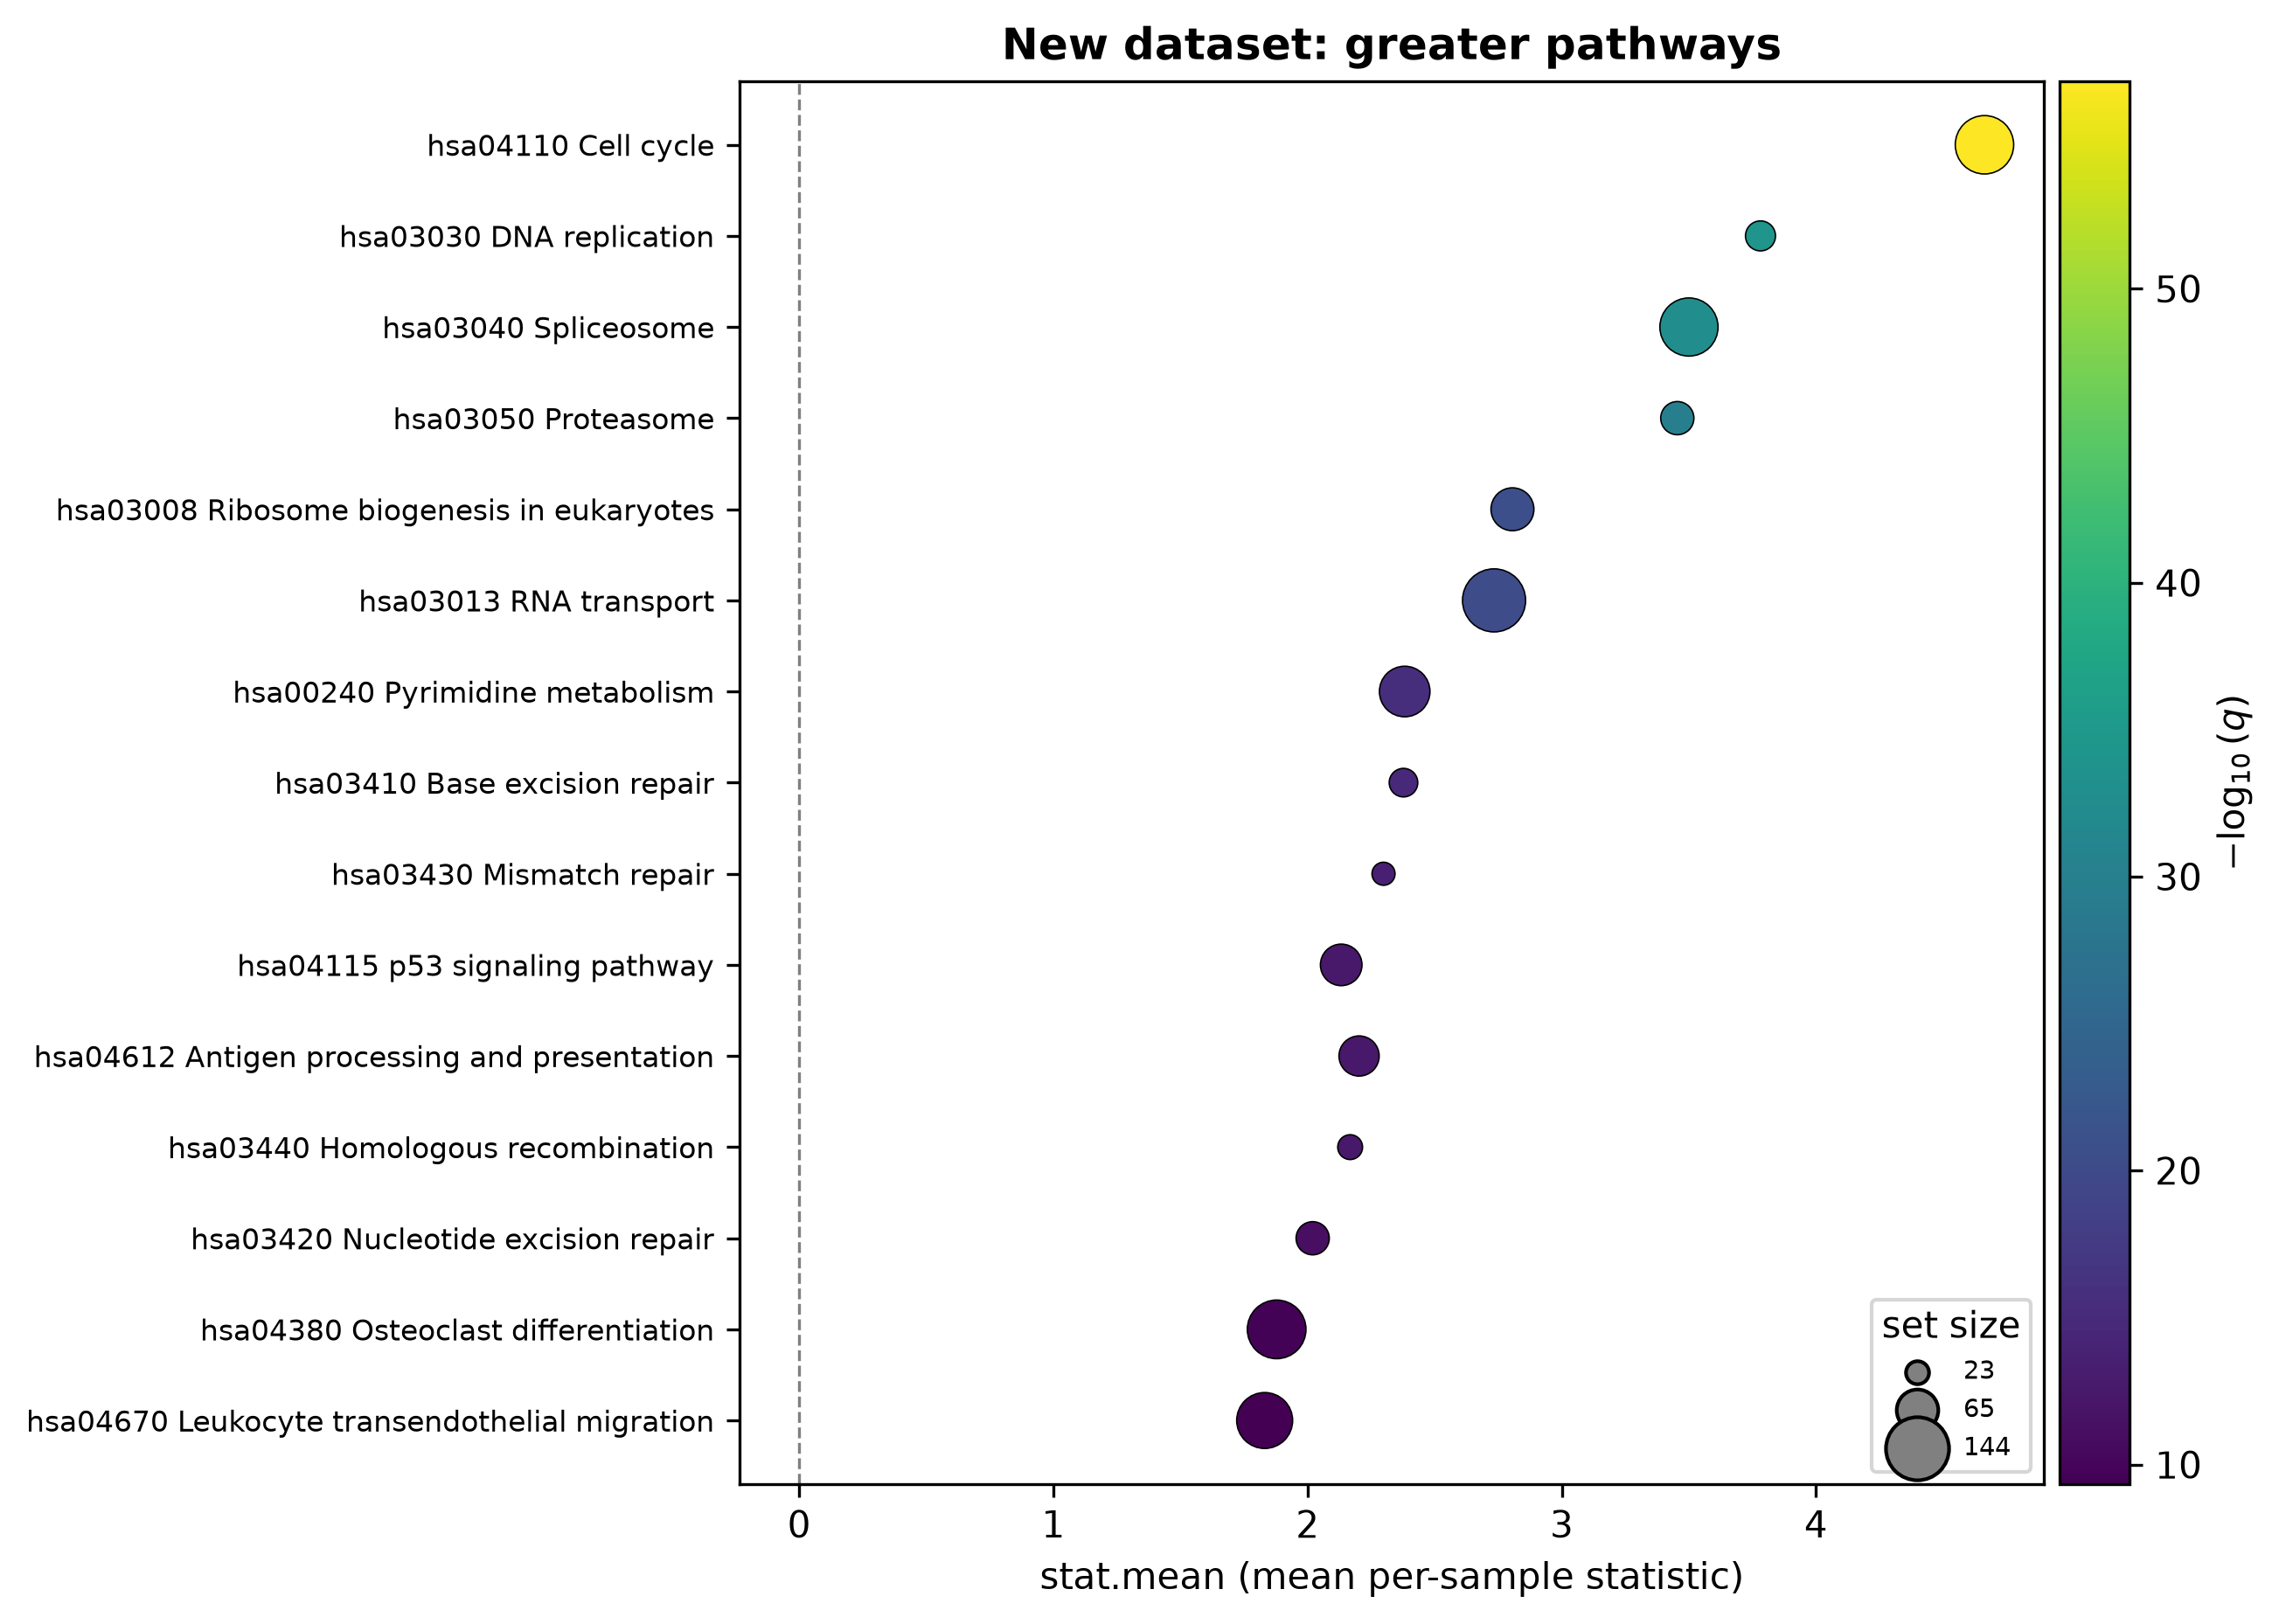

In [10]:
display(Image(
    filename=str(ROOT / "results" / "pygage" / "new_dataset_greater_bubble.png"),
    width=850,
))

## Part 6 — Numerical check against R GAGE

The repository includes reference tables created by R GAGE. The validation joined pathways by name and checked t/Stouffer, z/Stouffer, and t/Fisher results.

In [11]:
parity = pl.read_csv(ROOT / "results" / "pygage" / "r_gage_parity.csv")
parity

test_method,meta_method,common_gene_sets,max_abs_stat_difference,max_abs_p_difference
str,str,i64,f64,f64
"""t-test""","""stouffer""",160,4.8850e-15,1.4433e-15
"""z-test""","""stouffer""",160,5.7732e-15,2.1094e-15
"""t-test""","""fisher""",160,4.8850e-15,1.9984e-15


## Part 7 — Command line checks

These equivalent terminal workflows were also executed:

```bash
pygage run data/toy_expression.csv -g data/toy_sets.gmt           -o results/pygage/cli_run.csv --ref 0,1 --samp 2,3 --min-size 5

pygage go data/toy_annotations.gaf -o results/pygage/cli_go.json           --obo data/toy_go.obo --aspect BP --propagate

pygage compare results/pygage/toy_greater.csv results/pygage/toy_less.csv           -o results/pygage/cli_compare.csv --names greater,less
```

In [12]:
pl.read_csv(ROOT / "results" / "pygage" / "cli_run.csv").head()

gene_set,set_size,stat_mean,p_geomean,p_val,q_val,effect,direction
str,i64,f64,f64,f64,f64,f64,str
"""UP_SET""",10,3.283343,0.002761,0.000043,0.000174,1.86,"""greater"""
"""MIXED_SET""",10,0.035747,0.485912,0.480146,0.960292,0.26,"""greater"""
"""UNCHANGED_SET""",10,-0.510304,0.688414,0.757143,0.999812,0.01,"""greater"""
"""DOWN_SET""",10,-2.945822,0.99399,0.999812,0.999812,-1.17,"""greater"""
"""DOWN_SET""",10,-2.945822,0.005957,0.000188,0.000754,-1.17,"""less"""


## PyGAGE conclusion

The main classical PyGAGE engine, supported inputs, six statistic/meta-method combinations, result helpers, general charts, three CLI workflows, new 13-pair data analysis, and packaged R GAGE numerical regressions all executed.

See the full report for the exact test count and current compatibility notes.